#### 1. 環境設定、套件安裝與PHASE4資料讀取

In [11]:
# ============================================================
# Cell 1：環境設定、套件安裝與資料讀取
# ============================================================

# ------------------------------------------------------------
# 1. 安裝可能會用到的套件
# ------------------------------------------------------------
# 若已安裝，執行時會顯示 Requirement already satisfied，屬正常情況

import sys
import subprocess

packages = [
    "pandas",
    "numpy",
    "matplotlib",
    "seaborn",
    "geopandas",
    "shapely",
    "scikit-learn",
    "openpyxl"
]

for package in packages:
    subprocess.check_call([
        sys.executable,
        "-m",
        "pip",
        "install",
        package
    ])

print("套件安裝 / 檢查完成。")

# ------------------------------------------------------------
# 2. 匯入套件
# ------------------------------------------------------------

import os
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("套件匯入完成。")

# ------------------------------------------------------------
# 3. 設定資料路徑
# ------------------------------------------------------------

output_dir = Path("../output")

shelter_csv_path = output_dir / "shelter_gdf_twd97.csv"
risk_csv_path = output_dir / "shelters_flood_confidence.csv"

# 檢查 output 資料夾是否存在
if not output_dir.exists():
    raise FileNotFoundError(
        f"找不到 output 資料夾：{output_dir.resolve()}\n"
        "請確認目前 notebook 的位置是否正確，或確認 ../output 是否存在。"
    )

# 檢查 CSV 檔案是否存在
if not shelter_csv_path.exists():
    raise FileNotFoundError(
        f"找不到檔案：{shelter_csv_path.resolve()}"
    )

if not risk_csv_path.exists():
    raise FileNotFoundError(
        f"找不到檔案：{risk_csv_path.resolve()}"
    )

print("資料路徑檢查完成。")
print(f"shelter_gdf_twd97 路徑：{shelter_csv_path}")
print(f"shelters_flood_confidence 路徑：{risk_csv_path}")

# ------------------------------------------------------------
# 4. 讀取 CSV 檔案
# ------------------------------------------------------------

shelter_gdf_twd97 = pd.read_csv(
    shelter_csv_path,
    encoding="utf-8-sig"
)

shelters_flood_confidence = pd.read_csv(
    risk_csv_path,
    encoding="utf-8-sig"
)

print("CSV 資料讀取完成。")

# ------------------------------------------------------------
# 5. 初步檢查資料
# ------------------------------------------------------------

print("\n===== shelter_gdf_twd97 資料概況 =====")
print(f"資料筆數：{len(shelter_gdf_twd97)}")
print(f"欄位數量：{len(shelter_gdf_twd97.columns)}")
print("欄位名稱：")
print(shelter_gdf_twd97.columns.tolist())

print("\n前 5 筆資料：")
display(shelter_gdf_twd97.head())

print("\n===== shelters_flood_confidence 資料概況 =====")
print(f"資料筆數：{len(shelters_flood_confidence)}")
print(f"欄位數量：{len(shelters_flood_confidence.columns)}")
print("欄位名稱：")
print(shelters_flood_confidence.columns.tolist())

print("\n前 5 筆資料：")
display(shelters_flood_confidence.head())

print("\n第一個 Cell 執行完成。")

套件安裝 / 檢查完成。
套件匯入完成。
資料路徑檢查完成。
shelter_gdf_twd97 路徑：..\output\shelter_gdf_twd97.csv
shelters_flood_confidence 路徑：..\output\shelters_flood_confidence.csv
CSV 資料讀取完成。

===== shelter_gdf_twd97 資料概況 =====
資料筆數：198
欄位數量：25
欄位名稱：
['序號', '縣市及鄉鎮市區', '村里', '避難收容處所地址', '經度', '緯度', '避難收容處所名稱', '預計收容村里', '預計收容人數', '適用災害類別', '管理人姓名', '管理人電話', '室內', '室外', '適合避難弱者安置', 'is_indoor', 'geometry', 'debrisstream_level', 'Avg_slope', 'Max_elevation', 'Slope_risk_level', 'rain_1hr', 'sigma_1hr', 'rain_1hr_rf', 'village_A65UP_CNT']

前 5 筆資料：


,序號,縣市及鄉鎮市區,村里,避難收容處所地址,經度,緯度,避難收容處所名稱,預計收容村里,預計收容人數,適用災害類別,...,is_indoor,geometry,debrisstream_level,Avg_slope,Max_elevation,Slope_risk_level,rain_1hr,sigma_1hr,rain_1hr_rf,village_A65UP_CNT
0,46,花蓮縣秀林鄉,和平村,和平112號,121.748879,24.308073,和平國小,和中部落,250,"水災,土石流",...,True,POINT (326011.1106515807 2689346.507721314),Safe,1.550992,26.299999,Low,2.659960,0.131210,2.905000,247.0
1,1306,花蓮縣富里鄉,豐南村,豐南7鄰12-3號,121.268600,23.143000,豐南社區活動中心,豐南村,50,"水災,震災,土石流,海嘯",...,True,POINT (277505.7788830008 2560143.4173844056),High,5.911457,311.970001,Low,25.080535,0.109780,23.706667,177.0
2,1332,花蓮縣富里鄉,富南村,富南村4鄰42-1號,121.239900,23.161200,玉寶宮,富南村,20,"水災,土石流",...,True,POINT (274563.44670140836 2562153.6820209557),Safe,3.268415,248.050003,Low,27.263645,0.112761,26.725000,148.0
3,1342,花蓮縣富里鄉,永豐村,永豐10鄰20-1號,121.256500,23.171400,永豐社區活動中心,永豐村,50,"水災,土石流",...,True,POINT (276261.14500775794 2563286.0855803615),Low,8.039100,315.700012,Low,26.692346,0.100447,26.551667,124.0
4,1350,花蓮縣富里鄉,富里村,中山路205號,121.247624,23.174527,富里老人文康中心,富里村,100,"水災,土石流",...,True,POINT (275351.8038631432 2563630.784185125),Safe,4.229494,264.399994,Low,27.387960,0.103310,26.906667,379.0



===== shelters_flood_confidence 資料概況 =====
資料筆數：198
欄位數量：15
欄位名稱：
['避難收容處所名稱', '縣市及鄉鎮市區', '村里', '避難收容處所地址', '預計收容人數', '室內', '室外', '經度', '緯度', 'mean_elevation', 'max_slope', 'std_elevation', 'fusion_class', 'fusion_label', 'flood_confidence']

前 5 筆資料：


,避難收容處所名稱,縣市及鄉鎮市區,村里,避難收容處所地址,預計收容人數,室內,室外,經度,緯度,mean_elevation,max_slope,std_elevation,fusion_class,fusion_label,flood_confidence
0,和平國小,花蓮縣秀林鄉,和平村,和平112號,250,是,否,121.748879,24.308073,27.502351,45.473251,17.994240,9,無淹水(SAR無資料),low
1,豐南社區活動中心,花蓮縣富里鄉,豐南村,豐南7鄰12-3號,50,是,否,121.268600,23.143000,299.459149,41.046368,13.260633,0,無淹水,low
2,玉寶宮,花蓮縣富里鄉,富南村,富南村4鄰42-1號,20,是,否,121.239900,23.161200,240.630908,29.891891,7.838210,0,無淹水,low
3,永豐社區活動中心,花蓮縣富里鄉,永豐村,永豐10鄰20-1號,50,是,否,121.256500,23.171400,257.456815,32.286247,22.753039,0,無淹水,low
4,富里老人文康中心,花蓮縣富里鄉,富里村,中山路205號,100,是,否,121.247624,23.174527,238.324347,30.526333,18.284005,0,無淹水,low



第一個 Cell 執行完成。


#### 2. 依「避難收容處所名稱」合併淹水風險欄位

In [12]:
# ============================================================
# Cell 2：依「避難收容處所名稱」合併淹水風險欄位
# ============================================================

import pandas as pd

print("正在依照避難收容處所名稱合併風險資料...")

# ------------------------------------------------------------
# 1. 檢查必要資料是否存在
# ------------------------------------------------------------

required_vars = ["shelter_gdf_twd97", "shelters_flood_confidence"]

for var in required_vars:
    if var not in globals():
        raise NameError(f"缺少變數：{var}，請先執行前一個讀取 CSV 的 Cell。")

# ------------------------------------------------------------
# 2. 檢查必要欄位是否存在
# ------------------------------------------------------------

join_col = "避難收容處所名稱"
risk_cols = ["fusion_class", "fusion_label", "flood_confidence"]

if join_col not in shelter_gdf_twd97.columns:
    raise KeyError(
        f"shelter_gdf_twd97 缺少欄位：{join_col}\n"
        f"目前欄位有：{shelter_gdf_twd97.columns.tolist()}"
    )

if join_col not in shelters_flood_confidence.columns:
    raise KeyError(
        f"shelters_flood_confidence 缺少欄位：{join_col}\n"
        f"目前欄位有：{shelters_flood_confidence.columns.tolist()}"
    )

missing_risk_cols = [
    col for col in risk_cols
    if col not in shelters_flood_confidence.columns
]

if len(missing_risk_cols) > 0:
    raise KeyError(
        f"shelters_flood_confidence 缺少欄位：{missing_risk_cols}\n"
        f"目前欄位有：{shelters_flood_confidence.columns.tolist()}"
    )

# ------------------------------------------------------------
# 3. 建立乾淨的 join key，避免前後空白造成合併失敗
# ------------------------------------------------------------

shelter_merge = shelter_gdf_twd97.copy()
risk_merge = shelters_flood_confidence.copy()

shelter_merge["shelter_name_join_key"] = (
    shelter_merge[join_col]
    .astype(str)
    .str.strip()
    .str.replace("　", "", regex=False)
    .str.replace(" ", "", regex=False)
)

risk_merge["shelter_name_join_key"] = (
    risk_merge[join_col]
    .astype(str)
    .str.strip()
    .str.replace("　", "", regex=False)
    .str.replace(" ", "", regex=False)
)

# ------------------------------------------------------------
# 4. 只保留 shelters_flood_confidence 中需要合併的欄位
#    若同一避難所名稱重複，只保留第一筆
# ------------------------------------------------------------

risk_for_join = (
    risk_merge[["shelter_name_join_key"] + risk_cols]
    .drop_duplicates(subset=["shelter_name_join_key"], keep="first")
)

# ------------------------------------------------------------
# 5. 合併 fusion_class、fusion_label、flood_confidence
# ------------------------------------------------------------

shelter_gdf_twd97 = shelter_merge.merge(
    risk_for_join,
    how="left",
    on="shelter_name_join_key"
)

# 移除輔助 join 欄位
shelter_gdf_twd97 = shelter_gdf_twd97.drop(
    columns=["shelter_name_join_key"],
    errors="ignore"
)

# ------------------------------------------------------------
# 6. 檢查合併結果
# ------------------------------------------------------------

matched_count = shelter_gdf_twd97["fusion_class"].notna().sum()
total_count = len(shelter_gdf_twd97)

print("合併完成。")
print(f"成功匹配筆數：{matched_count}/{total_count}")
print(f"未匹配筆數：{total_count - matched_count}")

print("\n===== 合併後欄位檢查 =====")
print(shelter_gdf_twd97[[join_col] + risk_cols].head(10))

# ------------------------------------------------------------
# 7. 可選：輸出合併後 CSV
# ------------------------------------------------------------

output_csv_path = output_dir / "shelter_gdf_twd97_with_risk_new.csv"

shelter_gdf_twd97.to_csv(
    output_csv_path,
    index=False,
    encoding="utf-8-sig"
)

print(f"\n已輸出合併後檔案至：{output_csv_path}")

正在依照避難收容處所名稱合併風險資料...
合併完成。
成功匹配筆數：198/198
未匹配筆數：0

===== 合併後欄位檢查 =====
   避難收容處所名稱  fusion_class fusion_label flood_confidence
0      和平國小             9  無淹水(SAR無資料)              low
1  豐南社區活動中心             0          無淹水              low
2       玉寶宮             0          無淹水              low
3  永豐社區活動中心             0          無淹水              low
4  富里老人文康中心             0          無淹水              low
5  石平社區活動中心             0          無淹水              low
6   富里鄉公所2樓             0          無淹水              low
7  石牌社區活動中心             0          無淹水              low
8  明里社區活動中心             0          無淹水              low
9     羅山縱管處             0          無淹水              low

已輸出合併後檔案至：..\output\shelter_gdf_twd97_with_risk_new.csv


#### 3. 計算避難所風險分數

In [13]:
# ============================================================
# Cell：重新計算避難所風險分數，並拉大分數差異
# ============================================================

import numpy as np
import pandas as pd

print("正在重新計算避難所風險分數，並進行分數拉伸...")

# ------------------------------------------------------------
# 1. 檢查資料
# ------------------------------------------------------------

if "shelter_gdf_twd97" not in globals():
    raise NameError("找不到 shelter_gdf_twd97，請先讀取資料。")

df = shelter_gdf_twd97.copy()

# ------------------------------------------------------------
# 2. 處理欄位名稱差異
# ------------------------------------------------------------
# 你的資料中可能是 debrisstream_level，也可能是 debris_stream_level

if "debris_stream_level" not in df.columns and "debrisstream_level" in df.columns:
    df["debris_stream_level"] = df["debrisstream_level"]

required_cols = [
    "rain_1hr",
    "fusion_class",
    "debris_stream_level",
    "Max_elevation",
    "Slope_risk_level",
    "sigma_1hr",
    "village_A65UP_CNT"
]

missing_cols = [col for col in required_cols if col not in df.columns]

if len(missing_cols) > 0:
    raise KeyError(
        f"缺少必要欄位：{missing_cols}\n"
        f"目前欄位有：{df.columns.tolist()}"
    )

# ------------------------------------------------------------
# 3. 工具函數
# ------------------------------------------------------------

def minmax_normalize(series, higher_is_risk=True):
    """
    一般 min-max 標準化。
    數值越大越差時 higher_is_risk=True。
    """
    s = pd.to_numeric(series, errors="coerce")
    
    if s.notna().sum() == 0:
        return pd.Series(0, index=series.index)
    
    s = s.fillna(s.median())
    
    s_min = s.min()
    s_max = s.max()
    
    if s_max == s_min:
        norm = pd.Series(0, index=series.index)
    else:
        norm = (s - s_min) / (s_max - s_min)
    
    if not higher_is_risk:
        norm = 1 - norm
    
    return norm.clip(0, 1)


def robust_rescale_0_100(series, lower_q=0.05, upper_q=0.95):
    """
    將原始風險分數依第 5 與第 95 百分位數拉伸到 0-100。
    這可以讓分數落差更明顯，同時降低極端值影響。
    """
    s = pd.to_numeric(series, errors="coerce")
    
    if s.notna().sum() == 0:
        return pd.Series(0, index=series.index)
    
    s = s.fillna(s.median())
    
    q_low = s.quantile(lower_q)
    q_high = s.quantile(upper_q)
    
    if q_high == q_low:
        score = pd.Series(50, index=series.index)
    else:
        score = 100 * (s - q_low) / (q_high - q_low)
    
    return score.clip(0, 100)


def map_level_to_score(series):
    """
    Safe / Low / Medium / High 轉成 0-1 風險分數。
    """
    level_map = {
        "safe": 0.00,
        "low": 0.33,
        "medium": 0.67,
        "high": 1.00
    }
    
    s = (
        series
        .astype(str)
        .str.strip()
        .str.lower()
    )
    
    return s.map(level_map).fillna(0)


def map_fusion_class(series):
    """
    fusion_class 分數設定：
    x = 1        → 分數 2
    x = 2 或 3   → 分數 1
    x = 0、9、-1 → 分數 0
    
    其他無法判斷或缺失值 → 分數 0
    """
    s = pd.to_numeric(series, errors="coerce")
    
    def assign_score(x):
        if x == 1:
            return 2.0
        elif x in [2, 3]:
            return 1.0
        elif x in [0, 9, -1]:
            return 0.0
        else:
            return 0.0
    
    return s.apply(assign_score)

# ------------------------------------------------------------
# 4. 建立各項風險分數
# ------------------------------------------------------------

# 災害強度：rain_1hr 越大越差
df["risk_rain"] = minmax_normalize(
    df["rain_1hr"],
    higher_is_risk=True
)

# 淹水偵測：fusion_class 0/9/-1 = 無崩塌，1/2/3 = 有崩塌
df["risk_collapse"] = map_fusion_class(
    df["fusion_class"]
)

# 土石流 / 溪流風險
df["risk_debris_stream"] = map_level_to_score(
    df["debris_stream_level"]
)

# 最大高程：越大越差
df["risk_max_elevation"] = minmax_normalize(
    df["Max_elevation"],
    higher_is_risk=True
)

# 坡度風險等級
df["risk_slope_level"] = map_level_to_score(
    df["Slope_risk_level"]
)

# Kriging 不確定性：越大越差
df["risk_uncertainty"] = minmax_normalize(
    df["sigma_1hr"],
    higher_is_risk=True
)

# 社會脆弱度：高齡人口越多越差
# 使用 log1p，避免極端人口數過度影響
df["risk_elderly"] = minmax_normalize(
    np.log1p(pd.to_numeric(df["village_A65UP_CNT"], errors="coerce")),
    higher_is_risk=True
)

# ------------------------------------------------------------
# 5. 計算 Hazard 分數
# ------------------------------------------------------------

df["hazard_score"] = (
    0.15 * df["risk_rain"] +
    0.30 * df["risk_collapse"] +
    0.15 * df["risk_debris_stream"] +
    0.15 * df["risk_max_elevation"] +
    0.15 * df["risk_slope_level"] +
    0.10 * df["risk_uncertainty"]
).clip(0, 1)

# ------------------------------------------------------------
# 6. 社會脆弱度放大係數
# ------------------------------------------------------------

df["vulnerability_multiplier"] = (
    0.70 + 0.30 * df["risk_elderly"]
)

# ------------------------------------------------------------
# 7. 原始風險分數
# ------------------------------------------------------------

df["risk_raw"] = (
    df["hazard_score"] *
    df["vulnerability_multiplier"]
).clip(0, 1)

# ------------------------------------------------------------
# 8. 拉伸成 0-100 的相對風險分數
# ------------------------------------------------------------

df["shelter_risk_score"] = robust_rescale_0_100(
    df["risk_raw"],
    lower_q=0.05,
    upper_q=0.95
)

# ------------------------------------------------------------
# 9. 依照分數分類風險等級
# ------------------------------------------------------------

def classify_risk(score):
    if score < 25:
        return "Low"
    elif score < 50:
        return "Medium"
    elif score < 75:
        return "High"
    else:
        return "Very High"

df["shelter_risk_level"] = df["shelter_risk_score"].apply(classify_risk)

# ------------------------------------------------------------
# 10. 回寫結果
# ------------------------------------------------------------

shelter_gdf_twd97 = df.copy()

print("風險分數重新計算完成。")

# ------------------------------------------------------------
# 11. 檢查分數分布
# ------------------------------------------------------------

print("\n===== 原始風險分數 risk_raw 統計 =====")
print(shelter_gdf_twd97["risk_raw"].describe())

print("\n===== 拉伸後風險分數 shelter_risk_score 統計 =====")
print(shelter_gdf_twd97["shelter_risk_score"].describe())

print("\n===== 風險等級數量 =====")
print(shelter_gdf_twd97["shelter_risk_level"].value_counts())

print("\n===== 前 10 筆結果 =====")

display_cols = [
    "rain_1hr",
    "fusion_class",
    "debris_stream_level",
    "Max_elevation",
    "Slope_risk_level",
    "sigma_1hr",
    "village_A65UP_CNT",
    "hazard_score",
    "risk_elderly",
    "vulnerability_multiplier",
    "risk_raw",
    "shelter_risk_score",
    "shelter_risk_level"
]

if "避難收容處所名稱" in shelter_gdf_twd97.columns:
    display_cols = ["避難收容處所名稱"] + display_cols

display(shelter_gdf_twd97[display_cols].head(10))

正在重新計算避難所風險分數，並進行分數拉伸...
風險分數重新計算完成。

===== 原始風險分數 risk_raw 統計 =====
count    198.000000
mean       0.128563
std        0.081197
min        0.047903
25%        0.064062
50%        0.108018
75%        0.177084
max        0.643874
Name: risk_raw, dtype: float64

===== 拉伸後風險分數 shelter_risk_score 統計 =====
count    198.000000
mean      35.142178
std       32.785181
min        0.000000
25%        4.374378
50%       27.238996
75%       63.164901
max      100.000000
Name: shelter_risk_score, dtype: float64

===== 風險等級數量 =====
shelter_risk_level
Low          95
Medium       45
Very High    31
High         27
Name: count, dtype: int64

===== 前 10 筆結果 =====


,避難收容處所名稱,rain_1hr,fusion_class,debris_stream_level,Max_elevation,Slope_risk_level,sigma_1hr,village_A65UP_CNT,hazard_score,risk_elderly,vulnerability_multiplier,risk_raw,shelter_risk_score,shelter_risk_level
0,和平國小,2.659960,9,Safe,26.299999,Low,0.131210,247.0,0.066915,0.547008,0.864102,0.057822,1.128510,Low
1,豐南社區活動中心,25.080535,0,High,311.970001,Low,0.109780,177.0,0.313611,0.465202,0.839561,0.263296,100.000000,Very High
2,玉寶宮,27.263645,0,Safe,248.050003,Low,0.112761,148.0,0.164360,0.421335,0.826401,0.135827,41.704392,Medium
3,永豐社區活動中心,26.692346,0,Low,315.700012,Low,0.100447,124.0,0.216108,0.378013,0.813404,0.175783,62.487941,High
4,富里老人文康中心,27.387960,0,Safe,264.399994,Low,0.103310,379.0,0.163979,0.652272,0.895682,0.146873,47.450123,Medium
5,石平社區活動中心,27.843876,0,Safe,363.209991,Low,0.111826,143.0,0.178556,0.412916,0.823875,0.147108,47.572262,Medium
6,富里鄉公所2樓,27.387960,0,Safe,311.529999,Low,0.103310,379.0,0.169139,0.652272,0.895682,0.151494,49.853850,Medium
7,石牌社區活動中心,25.549289,0,Safe,234.949997,Low,0.100636,235.0,0.154187,0.534774,0.860432,0.132668,40.060980,Medium
8,明里社區活動中心,26.101571,0,Safe,250.229996,Low,0.100657,105.0,0.157621,0.337343,0.801203,0.126286,36.741364,Medium
9,羅山縱管處,24.207342,0,Safe,259.230011,Low,0.101780,117.0,0.152892,0.363797,0.809139,0.123711,35.401748,Medium


In [14]:
shelter_gdf_twd97

,序號,縣市及鄉鎮市區,村里,避難收容處所地址,經度,緯度,避難收容處所名稱,預計收容村里,預計收容人數,適用災害類別,...,risk_debris_stream,risk_max_elevation,risk_slope_level,risk_uncertainty,risk_elderly,hazard_score,vulnerability_multiplier,risk_raw,shelter_risk_score,shelter_risk_level
0,46,花蓮縣秀林鄉,和平村,和平112號,121.748879,24.308073,和平國小,和中部落,250,"水災,土石流",...,0.00,0.012983,0.33,0.100695,0.547008,0.066915,0.864102,0.057822,1.128510,Low
1,1306,花蓮縣富里鄉,豐南村,豐南7鄰12-3號,121.268600,23.143000,豐南社區活動中心,豐南村,50,"水災,震災,土石流,海嘯",...,1.00,0.221463,0.33,0.042525,0.465202,0.313611,0.839561,0.263296,100.000000,Very High
2,1332,花蓮縣富里鄉,富南村,富南村4鄰42-1號,121.239900,23.161200,玉寶宮,富南村,20,"水災,土石流",...,0.00,0.174815,0.33,0.050617,0.421335,0.164360,0.826401,0.135827,41.704392,Medium
3,1342,花蓮縣富里鄉,永豐村,永豐10鄰20-1號,121.256500,23.171400,永豐社區活動中心,永豐村,50,"水災,土石流",...,0.33,0.224185,0.33,0.017190,0.378013,0.216108,0.813404,0.175783,62.487941,High
4,1350,花蓮縣富里鄉,富里村,中山路205號,121.247624,23.174527,富里老人文康中心,富里村,100,"水災,土石流",...,0.00,0.186747,0.33,0.024961,0.652272,0.163979,0.895682,0.146873,47.450123,Medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
193,3392,花蓮縣新城鄉,新城村,博愛路66號,121.650200,24.128800,新城社區活動中心,新城村,23,"水災,震災,土石流,海嘯",...,0.00,0.011618,0.33,0.140778,0.643686,0.094122,0.893106,0.084061,14.777181,Low
194,3393,花蓮縣新城鄉,新城村,新興1街62號,121.645200,24.130100,興田社區活動中心,新城村,45,"水災,震災,土石流,海嘯",...,0.00,0.016982,0.33,0.089687,0.643686,0.093330,0.893106,0.083354,14.409368,Low
195,3437,花蓮縣秀林鄉,富世村,97號,121.627700,24.147300,富世活動中心,富世村,100,"水災,震災,土石流,海嘯",...,1.00,0.119839,0.33,0.036537,0.603637,0.263253,0.881091,0.231949,91.703959,Very High
196,3482,花蓮縣秀林鄉,崇德村,72號,121.652400,24.162000,崇德國小收容所,崇德,100,"水災,震災,土石流,海嘯",...,1.00,0.064828,0.33,0.082413,0.523001,0.251025,0.856900,0.215103,82.941188,Very High


In [15]:
import os

# 建立輸出資料夾路徑
output_dir = "../output"

# 如果 output 資料夾不存在，就自動建立
os.makedirs(output_dir, exist_ok=True)

# 設定輸出檔案路徑
output_csv_path = os.path.join(output_dir, "shelter_gdf_twd97_score_new.csv")

# 輸出 CSV
shelter_gdf_twd97.to_csv(output_csv_path, index=False, encoding="utf-8-sig")

print(f"已成功輸出檔案至：{output_csv_path}")

已成功輸出檔案至：../output\shelter_gdf_twd97_score_new.csv


#### 4. 依照花蓮縣各鄉鎮市區的避難所風險分數分群統計

In [16]:
# ============================================================
# Cell：依縣市及鄉鎮市區統計不同 shelter_risk_level 分布
# ============================================================

import pandas as pd
import numpy as np

print("正在依照縣市及鄉鎮市區統計避難所風險等級分布...")

# ------------------------------------------------------------
# 1. 檢查資料與必要欄位
# ------------------------------------------------------------

if "shelter_gdf_twd97" not in globals():
    raise NameError("找不到 shelter_gdf_twd97，請先執行前面的資料讀取或風險計算 Cell。")

df = shelter_gdf_twd97.copy()

group_col = "縣市及鄉鎮市區"
risk_col = "shelter_risk_level"

required_cols = [group_col, risk_col]

missing_cols = [col for col in required_cols if col not in df.columns]

if len(missing_cols) > 0:
    raise KeyError(
        f"缺少必要欄位：{missing_cols}\n"
        f"目前欄位有：{df.columns.tolist()}"
    )

# ------------------------------------------------------------
# 2. 清理分群欄位與風險等級欄位
# ------------------------------------------------------------

df[group_col] = (
    df[group_col]
    .astype(str)
    .str.strip()
    .str.replace("　", "", regex=False)
    .str.replace(" ", "", regex=False)
)

df[risk_col] = (
    df[risk_col]
    .astype(str)
    .str.strip()
)

# 避免 nan 字串被當成有效類別
df.loc[df[group_col].isin(["nan", "None", ""]), group_col] = np.nan
df.loc[df[risk_col].isin(["nan", "None", ""]), risk_col] = np.nan

df_valid = df.dropna(subset=[group_col, risk_col]).copy()

# ------------------------------------------------------------
# 3. 設定風險等級順序
# ------------------------------------------------------------

risk_order = ["Low", "Medium", "High", "Very High"]

# 若資料中有其他風險等級，也一併保留在後面
existing_levels = df_valid[risk_col].dropna().unique().tolist()
extra_levels = [level for level in existing_levels if level not in risk_order]
risk_order_final = risk_order + extra_levels

# ------------------------------------------------------------
# 4. 統計各行政區不同風險等級的避難所數量
# ------------------------------------------------------------

risk_count_table = pd.crosstab(
    df_valid[group_col],
    df_valid[risk_col]
)

# 補齊風險等級欄位
for level in risk_order_final:
    if level not in risk_count_table.columns:
        risk_count_table[level] = 0

risk_count_table = risk_count_table[risk_order_final]

# 加總每個行政區避難所總數
risk_count_table["total_shelters"] = risk_count_table.sum(axis=1)

# ------------------------------------------------------------
# 5. 計算各行政區不同風險等級比例
# ------------------------------------------------------------

risk_ratio_table = risk_count_table[risk_order_final].div(
    risk_count_table["total_shelters"],
    axis=0
) * 100

risk_ratio_table = risk_ratio_table.add_suffix("_ratio_pct")

# ------------------------------------------------------------
# 6. 合併數量表與比例表
# ------------------------------------------------------------

risk_summary_by_town = pd.concat(
    [risk_count_table, risk_ratio_table],
    axis=1
).reset_index()

# ------------------------------------------------------------
# 7. 加入高風險避難所統計
# ------------------------------------------------------------

high_risk_levels = ["High", "Very High"]

for level in high_risk_levels:
    if level not in risk_summary_by_town.columns:
        risk_summary_by_town[level] = 0

risk_summary_by_town["high_or_very_high_count"] = (
    risk_summary_by_town["High"] +
    risk_summary_by_town["Very High"]
)

risk_summary_by_town["high_or_very_high_ratio_pct"] = (
    risk_summary_by_town["high_or_very_high_count"] /
    risk_summary_by_town["total_shelters"] *
    100
)

# ------------------------------------------------------------
# 8. 排序：高風險比例高者排前面，其次看高風險數量
# ------------------------------------------------------------

risk_summary_by_town = risk_summary_by_town.sort_values(
    by=["high_or_very_high_ratio_pct", "high_or_very_high_count", "total_shelters"],
    ascending=[False, False, False]
).reset_index(drop=True)

# ------------------------------------------------------------
# 9. 顯示結果
# ------------------------------------------------------------

print("統計完成。")

print("\n===== 各縣市及鄉鎮市區風險等級分布：數量與比例 =====")
display(risk_summary_by_town)

print("\n===== 各風險等級總數 =====")
display(
    df_valid[risk_col]
    .value_counts()
    .reindex(risk_order_final)
    .fillna(0)
    .astype(int)
    .reset_index()
    .rename(columns={"index": "shelter_risk_level", risk_col: "count"})
)

print("\n===== 前 10 個高風險比例最高的行政區 =====")
display(
    risk_summary_by_town[
        [
            group_col,
            "total_shelters",
            "Low",
            "Medium",
            "High",
            "Very High",
            "high_or_very_high_count",
            "high_or_very_high_ratio_pct"
        ]
    ].head(10)
)

正在依照縣市及鄉鎮市區統計避難所風險等級分布...
統計完成。

===== 各縣市及鄉鎮市區風險等級分布：數量與比例 =====


shelter_risk_level,縣市及鄉鎮市區,Low,Medium,High,Very High,total_shelters,Low_ratio_pct,Medium_ratio_pct,High_ratio_pct,Very High_ratio_pct,high_or_very_high_count,high_or_very_high_ratio_pct
0,花蓮縣卓溪鄉,0,2,3,7,12,0.000000,16.666667,25.000000,58.333333,10,83.333333
1,花蓮縣玉里鎮,0,2,3,7,12,0.000000,16.666667,25.000000,58.333333,10,83.333333
2,花蓮縣秀林鄉,2,0,4,4,10,20.000000,0.000000,40.000000,40.000000,8,80.000000
3,花蓮縣豐濱鄉,2,1,3,1,7,28.571429,14.285714,42.857143,14.285714,4,57.142857
4,花蓮縣萬榮鄉,1,4,2,3,10,10.000000,40.000000,20.000000,30.000000,5,50.000000
5,花蓮縣光復鄉,7,2,2,3,14,50.000000,14.285714,14.285714,21.428571,5,35.714286
6,花蓮縣瑞穗鄉,3,8,4,1,16,18.750000,50.000000,25.000000,6.250000,5,31.250000
7,花蓮縣壽豐鄉,10,4,4,2,20,50.000000,20.000000,20.000000,10.000000,6,30.000000
8,花蓮縣富里鄉,0,9,2,1,12,0.000000,75.000000,16.666667,8.333333,3,25.000000
9,花蓮縣鳳林鎮,11,3,0,2,16,68.750000,18.750000,0.000000,12.500000,2,12.500000



===== 各風險等級總數 =====


,count,count
0,Low,95
1,Medium,45
2,High,27
3,Very High,31



===== 前 10 個高風險比例最高的行政區 =====


shelter_risk_level,縣市及鄉鎮市區,total_shelters,Low,Medium,High,Very High,high_or_very_high_count,high_or_very_high_ratio_pct
0,花蓮縣卓溪鄉,12,0,2,3,7,10,83.333333
1,花蓮縣玉里鎮,12,0,2,3,7,10,83.333333
2,花蓮縣秀林鄉,10,2,0,4,4,8,80.000000
3,花蓮縣豐濱鄉,7,2,1,3,1,4,57.142857
4,花蓮縣萬榮鄉,10,1,4,2,3,5,50.000000
5,花蓮縣光復鄉,14,7,2,2,3,5,35.714286
6,花蓮縣瑞穗鄉,16,3,8,4,1,5,31.250000
7,花蓮縣壽豐鄉,20,10,4,4,2,6,30.000000
8,花蓮縣富里鄉,12,0,9,2,1,3,25.000000
9,花蓮縣鳳林鎮,16,11,3,0,2,2,12.500000


In [17]:
import os

# 建立輸出資料夾路徑
output_dir = "../output"

# 如果 output 資料夾不存在，就自動建立
os.makedirs(output_dir, exist_ok=True)

# 設定輸出檔案路徑
output_csv_path = os.path.join(output_dir, "shelter_gdf_twd97_group_new.csv")

# 輸出 CSV
risk_summary_by_town.to_csv(output_csv_path, index=False, encoding="utf-8-sig")

print(f"已成功輸出檔案至：{output_csv_path}")



已成功輸出檔案至：../output\shelter_gdf_twd97_group_new.csv


#### 5. 載入花蓮縣鄉鎮市區界線圖資

鄉鎮市區界線圖資讀取完成。
總筆數：368
CRS：GEOGCS["GCS_TWD97[2020]",DATUM["Taiwan_Datum_1997",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","1026"]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433],AXIS["Longitude",EAST],AXIS["Latitude",NORTH]]
欄位名稱：
['TOWNID', 'TOWNCODE', 'COUNTYNAME', 'TOWNNAME', 'TOWNENG', 'COUNTYID', 'COUNTYCODE', 'geometry']

成功擷取花蓮縣。
HUALIEN 筆數：13
HUALIEN CRS：GEOGCS["GCS_TWD97[2020]",DATUM["Taiwan_Datum_1997",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","1026"]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433],AXIS["Longitude",EAST],AXIS["Latitude",NORTH]]

===== 花蓮縣鄉鎮市區列表 =====


,COUNTYNAME,TOWNNAME,geometry
0,花蓮縣,光復鄉,"POLYGON ((121.51468 23.71287, 121.5152 23.7128..."
1,花蓮縣,卓溪鄉,"POLYGON ((121.24213 23.61529, 121.24247 23.615..."
2,花蓮縣,吉安鄉,"POLYGON ((121.55764 23.99829, 121.55798 23.998..."
3,花蓮縣,壽豐鄉,"POLYGON ((121.51439 23.94801, 121.51512 23.947..."
4,花蓮縣,富里鄉,"POLYGON ((121.33526 23.29197, 121.33532 23.291..."
5,花蓮縣,新城鄉,"POLYGON ((121.6429 24.13307, 121.64313 24.1330..."
6,花蓮縣,玉里鎮,"POLYGON ((121.41399 23.49548, 121.41412 23.495..."
7,花蓮縣,瑞穗鄉,"POLYGON ((121.36673 23.5938, 121.3668 23.5938,..."
8,花蓮縣,秀林鄉,"POLYGON ((121.63176 24.36943, 121.63167 24.369..."
9,花蓮縣,花蓮市,"POLYGON ((121.64449 24.00306, 121.64389 24.001..."


Text(149.03222513628435, 0.5, 'Y')

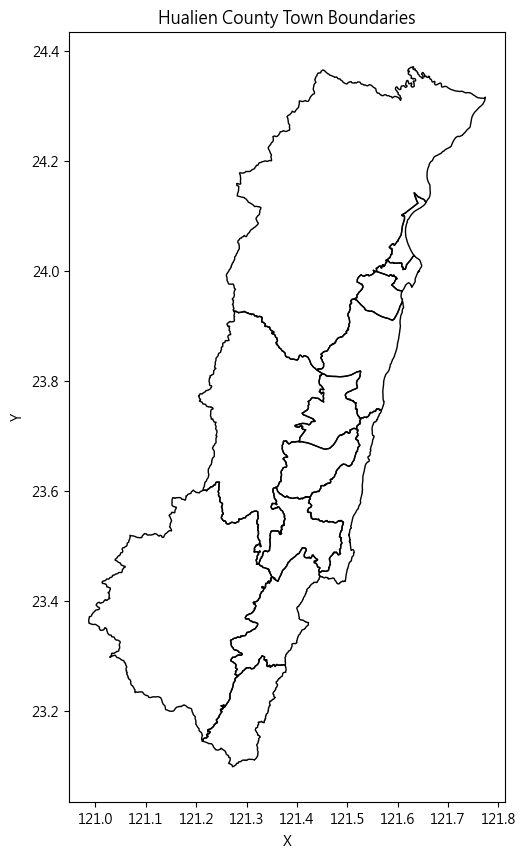

In [18]:
# ============================================================
# Cell：讀取鄉鎮市區界線圖資，擷取花蓮縣範圍
# ============================================================

from pathlib import Path
import geopandas as gpd
import pandas as pd

# ------------------------------------------------------------
# 1. 設定圖資路徑
# ------------------------------------------------------------

town_shp_path = Path("../data/鄉鎮市區界線/TOWN_MOI_1140318.shp")

if not town_shp_path.exists():
    raise FileNotFoundError(
        f"找不到圖資檔案：{town_shp_path.resolve()}\n"
        "請確認 ../data/鄉鎮市區界線/ 中是否有 TOWN_MOI_1140318.shp。"
    )

# ------------------------------------------------------------
# 2. 讀取鄉鎮市區界線圖資
# ------------------------------------------------------------

town_gdf = gpd.read_file(town_shp_path)

print("鄉鎮市區界線圖資讀取完成。")
print(f"總筆數：{len(town_gdf)}")
print(f"CRS：{town_gdf.crs}")
print("欄位名稱：")
print(town_gdf.columns.tolist())

# ------------------------------------------------------------
# 3. 檢查必要欄位
# ------------------------------------------------------------

required_cols = ["COUNTYNAME", "TOWNNAME"]

missing_cols = [
    col for col in required_cols
    if col not in town_gdf.columns
]

if len(missing_cols) > 0:
    raise KeyError(
        f"圖資缺少必要欄位：{missing_cols}\n"
        f"目前欄位有：{town_gdf.columns.tolist()}"
    )

# ------------------------------------------------------------
# 4. 清理文字欄位，避免空白造成篩選失敗
# ------------------------------------------------------------

town_gdf["COUNTYNAME_clean"] = (
    town_gdf["COUNTYNAME"]
    .astype(str)
    .str.strip()
    .str.replace("　", "", regex=False)
    .str.replace(" ", "", regex=False)
)

town_gdf["TOWNNAME_clean"] = (
    town_gdf["TOWNNAME"]
    .astype(str)
    .str.strip()
    .str.replace("　", "", regex=False)
    .str.replace(" ", "", regex=False)
)

# ------------------------------------------------------------
# 5. 擷取花蓮縣，儲存為 HUALIEN 變數
# ------------------------------------------------------------

HUALIEN = town_gdf[
    town_gdf["COUNTYNAME_clean"] == "花蓮縣"
].copy()

# 移除清理用欄位
HUALIEN = HUALIEN.drop(
    columns=["COUNTYNAME_clean", "TOWNNAME_clean"],
    errors="ignore"
)

if HUALIEN.empty:
    raise ValueError(
        "沒有篩選到花蓮縣。\n"
        "請檢查 COUNTYNAME 欄位中的實際文字內容。"
    )

print("\n成功擷取花蓮縣。")
print(f"HUALIEN 筆數：{len(HUALIEN)}")
print(f"HUALIEN CRS：{HUALIEN.crs}")

print("\n===== 花蓮縣鄉鎮市區列表 =====")
display(
    HUALIEN[["COUNTYNAME", "TOWNNAME", "geometry"]]
    .sort_values(by="TOWNNAME")
    .reset_index(drop=True)
)

# ------------------------------------------------------------
# 6. 簡單繪圖檢查
# ------------------------------------------------------------

ax = HUALIEN.plot(
    figsize=(8, 10),
    edgecolor="black",
    facecolor="none"
)

ax.set_title("Hualien County Town Boundaries")
ax.set_xlabel("X")
ax.set_ylabel("Y")

#### 6. 繪製花蓮縣鄉鎮市區避難所風險圖

In [19]:
# ============================================================
# Cell 5.5：將避難所風險統計結果合併到花蓮縣鄉鎮市區圖資
# ============================================================

import pandas as pd
import numpy as np
from matplotlib.patches import Patch

print("正在將避難所風險統計結果合併到 HUALIEN 圖資...")

# ------------------------------------------------------------
# 1. 檢查必要變數
# ------------------------------------------------------------

if "HUALIEN" not in globals():
    raise NameError("找不到 HUALIEN，請先執行第 5 步：讀取花蓮縣鄉鎮市區界線圖資。")

# 若 risk_summary_by_town 不存在，就嘗試從 output 讀取
if "risk_summary_by_town" not in globals():
    risk_summary_path = "../output/shelter_gdf_twd97_group_new.csv"
    
    try:
        risk_summary_by_town = pd.read_csv(risk_summary_path)
        print(f"已從 {risk_summary_path} 讀取 risk_summary_by_town。")
    except FileNotFoundError:
        raise NameError(
            "找不到 risk_summary_by_town，且 ../output/shelter_gdf_twd97_group_new.csv 不存在。\n"
            "請先執行第 4 步：依縣市及鄉鎮市區統計不同 shelter_risk_level 分布。"
        )

# ------------------------------------------------------------
# 2. 檢查必要欄位
# ------------------------------------------------------------

required_hualien_cols = ["COUNTYNAME", "TOWNNAME"]
required_summary_cols = [
    "縣市及鄉鎮市區",
    "total_shelters",
    "high_or_very_high_count",
    "high_or_very_high_ratio_pct"
]

missing_hualien_cols = [
    col for col in required_hualien_cols
    if col not in HUALIEN.columns
]

missing_summary_cols = [
    col for col in required_summary_cols
    if col not in risk_summary_by_town.columns
]

if len(missing_hualien_cols) > 0:
    raise KeyError(
        f"HUALIEN 缺少欄位：{missing_hualien_cols}\n"
        f"目前欄位有：{HUALIEN.columns.tolist()}"
    )

if len(missing_summary_cols) > 0:
    raise KeyError(
        f"risk_summary_by_town 缺少欄位：{missing_summary_cols}\n"
        f"目前欄位有：{risk_summary_by_town.columns.tolist()}"
    )

# ------------------------------------------------------------
# 3. 建立 join key
# ------------------------------------------------------------
# HUALIEN 裡通常是 COUNTYNAME + TOWNNAME
# risk_summary_by_town 裡是「縣市及鄉鎮市區」
# 因此兩邊都清理成一致格式後再合併。

HUALIEN = HUALIEN.copy()
risk_summary_for_join = risk_summary_by_town.copy()

HUALIEN["TOWNNAME_join"] = (
    HUALIEN["TOWNNAME"]
    .astype(str)
    .str.strip()
)

HUALIEN["town_join_key"] = (
    HUALIEN["COUNTYNAME"].astype(str) +
    HUALIEN["TOWNNAME"].astype(str)
)

HUALIEN["town_join_key"] = (
    HUALIEN["town_join_key"]
    .str.strip()
    .str.replace("　", "", regex=False)
    .str.replace(" ", "", regex=False)
)

risk_summary_for_join["town_join_key"] = (
    risk_summary_for_join["縣市及鄉鎮市區"]
    .astype(str)
    .str.strip()
    .str.replace("　", "", regex=False)
    .str.replace(" ", "", regex=False)
)

# ------------------------------------------------------------
# 4. 合併風險統計結果到 HUALIEN
# ------------------------------------------------------------

HUALIEN = HUALIEN.merge(
    risk_summary_for_join,
    how="left",
    on="town_join_key"
)

# ------------------------------------------------------------
# 5. 補齊沒有避難所統計資料的鄉鎮
# ------------------------------------------------------------

count_cols = [
    "Low",
    "Medium",
    "High",
    "Very High",
    "total_shelters",
    "high_or_very_high_count"
]

for col in count_cols:
    if col in HUALIEN.columns:
        HUALIEN[col] = HUALIEN[col].fillna(0)

if "high_or_very_high_ratio_pct" in HUALIEN.columns:
    HUALIEN["high_or_very_high_ratio_pct"] = (
        HUALIEN["high_or_very_high_ratio_pct"]
        .fillna(0)
    )

# ------------------------------------------------------------
# 6. 建立風險比例分級欄位 risk_ratio_class
# ------------------------------------------------------------

def classify_risk_ratio(value):
    """
    依 High + Very High 避難所比例進行分級。
    """
    if pd.isna(value):
        return "No Data"
    elif value == 0:
        return "0%"
    elif value <= 25:
        return "0-25%"
    elif value <= 50:
        return "25-50%"
    elif value <= 75:
        return "50-75%"
    else:
        return "75-100%"

HUALIEN["risk_ratio_class"] = HUALIEN["high_or_very_high_ratio_pct"].apply(
    classify_risk_ratio
)

# ------------------------------------------------------------
# 7. 建立分級顏色欄位 risk_ratio_color
# ------------------------------------------------------------
# 顏色邏輯：比例越高越紅。

class_order = [
    "0%",
    "0-25%",
    "25-50%",
    "50-75%",
    "75-100%",
    "No Data"
]

class_color_map = {
    "0%": "#f0f0f0",
    "0-25%": "#fee5d9",
    "25-50%": "#fcae91",
    "50-75%": "#fb6a4a",
    "75-100%": "#cb181d",
    "No Data": "#d9d9d9"
}

HUALIEN["risk_ratio_color"] = (
    HUALIEN["risk_ratio_class"]
    .map(class_color_map)
    .fillna("#d9d9d9")
)

# ------------------------------------------------------------
# 8. 檢查合併結果
# ------------------------------------------------------------

print("合併完成。")

print("\n===== HUALIEN 新增欄位檢查 =====")
print([
    col for col in [
        "TOWNNAME_join",
        "total_shelters",
        "High",
        "Very High",
        "high_or_very_high_count",
        "high_or_very_high_ratio_pct",
        "risk_ratio_class",
        "risk_ratio_color"
    ]
    if col in HUALIEN.columns
])

print("\n===== 各鄉鎮市區風險比例分級 =====")
display(
    HUALIEN[
        [
            "COUNTYNAME",
            "TOWNNAME",
            "total_shelters",
            "High",
            "Very High",
            "high_or_very_high_count",
            "high_or_very_high_ratio_pct",
            "risk_ratio_class",
            "risk_ratio_color"
        ]
    ].sort_values(
        by="high_or_very_high_ratio_pct",
        ascending=False
    ).reset_index(drop=True)
)

print("\n===== 未成功合併到統計資料的鄉鎮市區 =====")
unmatched_towns = HUALIEN[
    HUALIEN["total_shelters"].isna() |
    (HUALIEN["total_shelters"] == 0)
][["COUNTYNAME", "TOWNNAME", "town_join_key"]]

display(unmatched_towns)

正在將避難所風險統計結果合併到 HUALIEN 圖資...
合併完成。

===== HUALIEN 新增欄位檢查 =====
['TOWNNAME_join', 'total_shelters', 'High', 'Very High', 'high_or_very_high_count', 'high_or_very_high_ratio_pct', 'risk_ratio_class', 'risk_ratio_color']

===== 各鄉鎮市區風險比例分級 =====


,COUNTYNAME,TOWNNAME,total_shelters,High,Very High,high_or_very_high_count,high_or_very_high_ratio_pct,risk_ratio_class,risk_ratio_color
0,花蓮縣,玉里鎮,12,3,7,10,83.333333,75-100%,#cb181d
1,花蓮縣,卓溪鄉,12,3,7,10,83.333333,75-100%,#cb181d
2,花蓮縣,秀林鄉,10,4,4,8,80.000000,75-100%,#cb181d
3,花蓮縣,豐濱鄉,7,3,1,4,57.142857,50-75%,#fb6a4a
4,花蓮縣,萬榮鄉,10,2,3,5,50.000000,25-50%,#fcae91
5,花蓮縣,光復鄉,14,2,3,5,35.714286,25-50%,#fcae91
6,花蓮縣,瑞穗鄉,16,4,1,5,31.250000,25-50%,#fcae91
7,花蓮縣,壽豐鄉,20,4,2,6,30.000000,25-50%,#fcae91
8,花蓮縣,富里鄉,12,2,1,3,25.000000,0-25%,#fee5d9
9,花蓮縣,鳳林鎮,16,0,2,2,12.500000,0-25%,#fee5d9



===== 未成功合併到統計資料的鄉鎮市區 =====


,COUNTYNAME,TOWNNAME,town_join_key


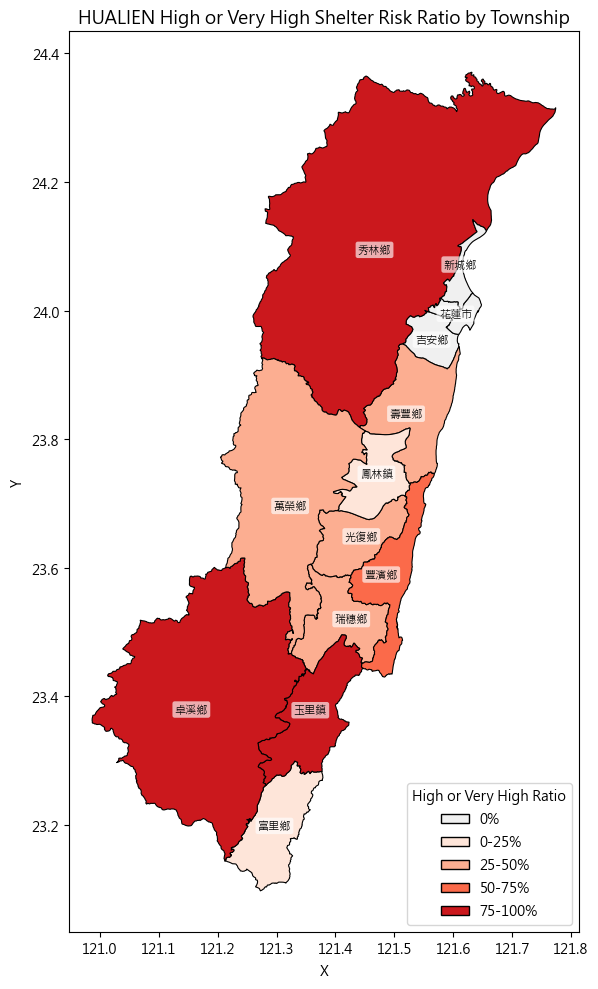

HUALIEN 已成功加入風險統計欄位，並完成離散 class 地圖繪製與鄉鎮市區標註。


In [20]:
# ------------------------------------------------------------
# 10. 離散 class 繪圖，並標示 TOWNNAME_join 名稱
# ------------------------------------------------------------
import matplotlib.pyplot as plt
import matplotlib as mpl

# ------------------------------------------------------------
# 設定中文字型：Windows 常用 Microsoft JhengHei
# ------------------------------------------------------------

plt.rcParams["font.sans-serif"] = [
    "Microsoft JhengHei",  # Windows 微軟正黑體
    "SimHei",              # 黑體，部分環境可用
    "Noto Sans CJK TC",    # Linux / Colab 常見
    "Arial Unicode MS"     # macOS 常見
]

plt.rcParams["axes.unicode_minus"] = False

fig, ax = plt.subplots(figsize=(8, 10))

# 繪製花蓮縣鄉鎮市區分級圖
HUALIEN.plot(
    ax=ax,
    color=HUALIEN["risk_ratio_color"],
    edgecolor="black",
    linewidth=0.8
)

# ------------------------------------------------------------
# 10.1 在每個鄉鎮市區上標示 TOWNNAME_join
# ------------------------------------------------------------
# 使用 representative_point()，可以確保標籤點落在 polygon 內部，
# 比 centroid 更適合用於形狀不規則的行政區。

for idx, row in HUALIEN.iterrows():
    label_point = row.geometry.representative_point()
    
    ax.text(
        label_point.x,
        label_point.y,
        row["TOWNNAME_join"],
        fontsize=8,
        ha="center",
        va="center",
        color="black",
        bbox=dict(
            boxstyle="round,pad=0.2",
            facecolor="white",
            edgecolor="none",
            alpha=0.65
        )
    )

# ------------------------------------------------------------
# 10.2 建立離散圖例
# ------------------------------------------------------------

legend_handles = [
    Patch(
        facecolor=class_color_map[class_name],
        edgecolor="black",
        label=class_name
    )
    for class_name in class_order
    if class_name in HUALIEN["risk_ratio_class"].astype(str).unique()
]

ax.legend(
    handles=legend_handles,
    title="High or Very High Ratio",
    loc="lower right",
    frameon=True
)

# ------------------------------------------------------------
# 10.3 圖面設定
# ------------------------------------------------------------

ax.set_title(
    "HUALIEN High or Very High Shelter Risk Ratio by Township",
    fontsize=13
)

ax.set_xlabel("X")
ax.set_ylabel("Y")

plt.tight_layout()
plt.show()

print("HUALIEN 已成功加入風險統計欄位，並完成離散 class 地圖繪製與鄉鎮市區標註。")